In [1]:
%cd ../

/home/dmoreno/pipeline_v4_final/pipeline/training/lc_classifiers/models/paper_versions/ztf_ff


In [2]:
%ls

data/             images_old/  notebooks/    README.md      schema.py
download_data.sh  models/      __pycache__/  results_prod/


# Bottom level new taxonomy classifiers results

In [3]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import os
#os.environ["PATH"] = "/home/users/dmoreno2016/.TinyTeX/bin/x86_64-linux:" + os.environ["PATH"]

#plt.rcParams.update({
#    "text.usetex": True,
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "font.serif": ["Palatino"],
#})

import warnings
warnings.filterwarnings('ignore')

In [4]:
order_classes = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "Microlensing", "QSO", "AGN", "Blazar", 
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"
]

class_hierarchy = {
    "Transient": ["SNIa", "SESN", "SNII", "SNIIn", "SLSN", "TDE"],
    "Periodic": ["LPV", "EA", "EB/EW", "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"],
    "Stochastic": ["QSO", "AGN", "Blazar", "YSO", "CV/Nova", "Microlensing"],
}

# Lista de días evaluados
list_time_eval = ['8', '16', '32', '64', '128', '256', '512', '1024', 'None']

path_save_imgs = 'images'

os.makedirs(f'{path_save_imgs}', exist_ok=True)

In [5]:
mlflow.set_tracking_uri("file:./models/ATAT/results/ml-runs")

data_name =  'ztf_ff_20folds'
experiment_name = f"classification/{data_name}/testing"

experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment:
    experiment_id = experiment.experiment_id
    print(f"Experiment ID for '{experiment_name}': {experiment_id}")
else:
    print(f"Experiment '{experiment_name}' not found.")

runs = mlflow.search_runs(experiment_ids=[experiment_id])
runs = runs[
    (runs.status == 'FINISHED') & 
    (runs['metrics.mix/f1s_test/None_days'].notna())
    ]

# Identificadores de cada fold
fold_run = {v: k for k, v in zip(runs['run_id'], runs['params.general/fold'])}

display(runs.head())
print(runs.shape)
print(fold_run)

Experiment ID for 'classification/ztf_ff_20folds/testing': 962229171665423791


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.loss_train/total,metrics.loss_test/16_days/tab_ce,metrics.loss_test/256_days/tab_entropy,metrics.loss_test/256_days/lc,...,params.general/use_time_nondetection,params.ft/embedding_size_sub,params.lc/num_encoders,params.general/experiment_type,tags.mlflow.parentRunId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.source.git.commit,tags.mlflow.source.type,tags.mlflow.runName
0,dcbfbec41dbf4a008a0b2f4f3809614d,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-07 11:21:00.885000+00:00,2026-02-07 17:31:39.408000+00:00,1.667568,0.740888,-0.320775,1.271436,...,False,128,2,lc_md_feat_mta,93a3c947d5964aa69440af94e4facc44,training.py,dmoreno,6ed63fd1e72375e122564f67cd157af5f7605281,LOCAL,Fold_19_2026-02-07_02-46-14
1,d516bf190eb044c48e71aa087daec9ad,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-07 02:46:14.298000+00:00,2026-02-07 11:21:00.881000+00:00,1.394584,0.721491,-0.308582,1.241027,...,False,128,2,lc_md_feat_mta,93a3c947d5964aa69440af94e4facc44,training.py,dmoreno,6ed63fd1e72375e122564f67cd157af5f7605281,LOCAL,Fold_18_2026-02-07_02-46-14
3,0b3d05b786154f669547663574bb2b94,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 13:43:28.361000+00:00,2026-02-06 22:10:40.014000+00:00,1.496183,0.719899,-0.299140,1.254098,...,False,128,2,lc_md_feat_mta,fa103dedc1b6410791914ad67bb7a893,training.py,dmoreno,6ed63fd1e72375e122564f67cd157af5f7605281,LOCAL,Fold_14_2026-02-05_18-44-25
4,bb2d6a5e93af4dd3a27f5439d1c297cb,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 08:07:49.485000+00:00,2026-02-06 14:37:41.611000+00:00,1.785463,0.755682,-0.343988,1.281898,...,False,128,2,lc_md_feat_mta,01eacf7990894d68b04250b6e764ec06,training.py,dmoreno,6ed63fd1e72375e122564f67cd157af5f7605281,LOCAL,Fold_17_2026-02-05_18-46-07
5,2da58ec77ef7470e8987dd991ab265a4,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 03:17:33.812000+00:00,2026-02-06 13:43:28.357000+00:00,1.481791,0.711232,-0.289222,1.233496,...,False,128,2,lc_md_feat_mta,fa103dedc1b6410791914ad67bb7a893,training.py,dmoreno,6ed63fd1e72375e122564f67cd157af5f7605281,LOCAL,Fold_13_2026-02-05_18-44-25


(20, 214)
{'19': 'dcbfbec41dbf4a008a0b2f4f3809614d', '18': 'd516bf190eb044c48e71aa087daec9ad', '14': '0b3d05b786154f669547663574bb2b94', '17': 'bb2d6a5e93af4dd3a27f5439d1c297cb', '13': '2da58ec77ef7470e8987dd991ab265a4', '16': 'e687ac031e42466c83b19d4ed7cec1c5', '15': 'b2d113b4bef94e94ab123c0e34deb6a9', '12': '7cee5e534275413a9d2e45accda17bfc', '11': '40b50aeb8bae4db3af2ae30c9737de05', '8': 'e4c429d353714261838546b48aefc7fa', '10': 'd9af533c04274318b47b94e1874b68b3', '7': '51a58a2ff9814ac7815d72745c8c756e', '9': 'b410a7b202c14ca49612c8da1e8883ca', '6': '479b33e2708d4c75aab5db562691ae93', '5': 'd3a7920e140d4345b11190d1c800dad8', '2': '8eda2f2d74c140aa8ea3edd93ed6d0d6', '4': 'f4278fd6d3d04015b065722e135ca8af', '1': 'e70d10ce7f024bd582d714e0db72d3ee', '3': 'd5f7f1ca1ef848d8ba1e5dfc406dacd4', '0': '83a5f4135292475ca54b0c15122f3db6'}


## ATAT and HBRF predictions

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Inicializar estructuras para almacenar resultados
atat_y_pred_fold = {}
hbrf_y_pred_fold = {}
combined_y_pred_fold = {}
y_test_fold = {}

# Iterar sobre los valores de time_eval (días)
for time_eval in list_time_eval:
    atat_y_pred_fold[f'{time_eval}_days'] = []
    hbrf_y_pred_fold[f'{time_eval}_days'] = []
    combined_y_pred_fold[f'{time_eval}_days'] = []
    y_test_fold[f'{time_eval}_days'] = []  # Guardar valores reales (y_true)

    for fold, run_id in fold_run.items():
        # Cargar predicciones de ATAT
        path_clf_report = f'./models/ATAT/results/ml-runs/{experiment_id}/{run_id}/artifacts'
        atat_df_predictions = pd.read_parquet(f'{path_clf_report}/ndays_results/LCs/predictions_test_{time_eval}.parquet').set_index('id')
        y_test = atat_df_predictions['y_true'].values
        atat_y_pred = atat_df_predictions['y_pred'].values

        # Cargar predicciones de HBRF
        root = 'models/HBRF/results/250408_ndetge8_20folds/HBRF_20251229-182152'
        hbrf_df_predictions = pd.read_parquet(f'{root}/fold_{fold}/predictions_test.parquet')
        hbrf_df_predictions = hbrf_df_predictions[hbrf_df_predictions['shorten'] == time_eval]
        hbrf_df_predictions.index = hbrf_df_predictions.index.astype(str).str.split('_').str[1]
        hbrf_df_predictions = hbrf_df_predictions.reindex(atat_df_predictions.index)
        hbrf_y_pred = hbrf_df_predictions['y_pred'].values

        # Promediar predicciones de ATAT y HBRF
        combined_y_pred_prob_fold = (atat_df_predictions[order_classes] + hbrf_df_predictions[order_classes]) / 2
        
        # Guardar valores en estructuras
        atat_y_pred_fold[f'{time_eval}_days'].append(atat_y_pred)
        hbrf_y_pred_fold[f'{time_eval}_days'].append(hbrf_y_pred)
        combined_y_pred_fold[f'{time_eval}_days'].append(combined_y_pred_prob_fold.idxmax(axis=1))
        y_test_fold[f'{time_eval}_days'].append(y_test)


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

metrics_by_time = {time_eval: {"ATAT": [], "HBRF": [], "Combined": []} for time_eval in list_time_eval}
confusion_matrices = {} 

for time_eval in list_time_eval:
    for fold in range(len(fold_run)):  # Iterar sobre los folds
        y_test = y_test_fold[f"{time_eval}_days"][fold]
        y_pred_atat = atat_y_pred_fold[f"{time_eval}_days"][fold]
        y_pred_hbrf = hbrf_y_pred_fold[f"{time_eval}_days"][fold]
        y_pred_combined = combined_y_pred_fold[f"{time_eval}_days"][fold]

        # Calcular reporte de métricas inter
        report_atat_inter = classification_report(y_test, y_pred_atat, output_dict=True)
        report_hbrf_inter = classification_report(y_test, y_pred_hbrf, output_dict=True)
        report_combined_inter = classification_report(y_test, y_pred_combined, output_dict=True)

        # Guardar métricas
        metrics_by_time[time_eval]["ATAT"].append(report_atat_inter)
        metrics_by_time[time_eval]["HBRF"].append(report_hbrf_inter)
        metrics_by_time[time_eval]["Combined"].append(report_combined_inter)

        # Guardar matrices de confusión solo cuando time_eval es None
        if time_eval == 'None':
            if time_eval not in confusion_matrices:
                confusion_matrices[time_eval] = {"ATAT": [], "HBRF": [], "Combined": []}
            
            cm_atat = confusion_matrix(y_test, y_pred_atat, labels=order_classes)
            cm_hbrf = confusion_matrix(y_test, y_pred_hbrf, labels=order_classes)
            cm_combined = confusion_matrix(y_test, y_pred_combined, labels=order_classes)

            confusion_matrices[time_eval]["ATAT"].append(cm_atat)
            confusion_matrices[time_eval]["HBRF"].append(cm_hbrf)
            confusion_matrices[time_eval]["Combined"].append(cm_combined)

In [8]:
import pandas as pd
import numpy as np

# Diccionario dinámico para almacenar los datos de cada categoría
data_inter = {category: [] for category in order_classes}
data_inter_macro = []

for time_eval in list_time_eval:
    for category in order_classes:
        row = [time_eval]
        for model in ["ATAT", "HBRF", "Combined"]:
            recalls = [metrics_by_time[time_eval][model][fold][category]["recall"] * 100 
                       for fold in range(len(fold_run))]
            precision = [metrics_by_time[time_eval][model][fold][category]["precision"] * 100 
                         for fold in range(len(fold_run))]
            f1_score = [metrics_by_time[time_eval][model][fold][category]["f1-score"] * 100 
                        for fold in range(len(fold_run))]

            row.extend([
                f"{np.mean(precision):.2f} ± {np.std(precision):.2f}",
                f"{np.mean(recalls):.2f} ± {np.std(recalls):.2f}",
                f"{np.mean(f1_score):.2f} ± {np.std(f1_score):.2f}"
            ])

        # Guardar la fila en el diccionario correspondiente a la categoría
        data_inter[category].append(row)

    # Calcular y guardar macro promedio por cada time_eval
    row_macro = [time_eval]
    for model in ["ATAT", "HBRF", "Combined"]:
        macro_precision = [metrics_by_time[time_eval][model][fold]["macro avg"]["precision"] * 100 
                           for fold in range(len(fold_run))]
        macro_recall = [metrics_by_time[time_eval][model][fold]["macro avg"]["recall"] * 100 
                        for fold in range(len(fold_run))]
        macro_f1 = [metrics_by_time[time_eval][model][fold]["macro avg"]["f1-score"] * 100 
                    for fold in range(len(fold_run))]

        row_macro.extend([
            f"{np.mean(macro_precision)} ± {np.std(macro_precision)}",
            f"{np.mean(macro_recall)} ± {np.std(macro_recall)}",
            f"{np.mean(macro_f1)} ± {np.std(macro_f1)}"
        ])
    
    data_inter_macro.append(row_macro)

# Crear DataFrames para cada categoría dinámicamente
columns = ["Time (days)", 
           "ATAT Precision", "ATAT Recall", "ATAT F1-score",
           "HBRF Precision", "HBRF Recall", "HBRF F1-score",
           "Combined Precision", "Combined Recall", "Combined F1-score"]

df_inter = {category: pd.DataFrame(data, columns=columns).set_index("Time (days)") 
            for category, data in data_inter.items()}

# Crear DataFrame para Macro Promedio
df_inter_macro = pd.DataFrame(data_inter_macro, columns=columns).set_index("Time (days)")

# -------------------------------
# **MOSTRAR RESULTADOS**
# -------------------------------
display(df_inter_macro.head())
print(f'Number of classes: {len(df_inter)}')

,ATAT Precision,ATAT Recall,ATAT F1-score,HBRF Precision,HBRF Recall,HBRF F1-score,Combined Precision,Combined Recall,Combined F1-score
Time (days),,,,,,,,,
8,63.794827751069946 ± 1.7007019791043747,60.86082345322209 ± 1.3341198297241514,60.85791559417428 ± 1.4546816367033961,54.216898339422436 ± 0.3079190737813134,61.15006319053556 ± 0.5162777419603977,54.74159581177962 ± 0.34580026395808133,63.95995221315526 ± 1.926520615991879,62.2800278085655 ± 1.3250651141090233,61.93869285864524 ± 1.470083350781541
16,69.47081427683341 ± 1.3643583681966078,65.90633289131429 ± 1.306465770571851,66.48947540675692 ± 1.3012373520376703,60.6260965180954 ± 0.4314694158072603,66.79775056843366 ± 0.5482031160657256,61.69863730879492 ± 0.4328282049083574,69.87662656116923 ± 1.7215742926430984,67.21624391726232 ± 1.1650606560137948,67.59958158703452 ± 1.1829394671040867
32,74.08978871636492 ± 1.4614605733503492,70.97707601997445 ± 0.5497055126019281,71.79568676345711 ± 0.7322768379828729,68.17351622454004 ± 0.3279983627045359,73.14463046363132 ± 0.31997814437425764,69.49987312603403 ± 0.33947256582487195,74.99112125519214 ± 1.6314738736100194,72.50936485119313 ± 0.6633627350696452,73.1370440203063 ± 0.8727953432694304
64,77.12594743529196 ± 1.0858704136815804,74.07743136893683 ± 0.7013740051251601,74.97793757846327 ± 0.6603950664881901,71.90993776671448 ± 0.36267627746568093,76.41655950802665 ± 0.4709873801626392,73.33492131111086 ± 0.3832971589663468,77.87158446029034 ± 1.1595057123259151,75.28756882447654 ± 0.7021808910095237,76.07746882640187 ± 0.7006150027190189
128,78.97021004540224 ± 1.1288454985092984,75.81431835879215 ± 0.5636484738475669,76.83145907213769 ± 0.5609733200681497,73.383316949038 ± 0.28109352879136346,77.62916983469718 ± 0.26483484007522756,74.7996045969306 ± 0.2829200641651986,79.72680498397145 ± 1.220206388863042,76.95470211053991 ± 0.5631473388057473,77.87401570514143 ± 0.6196911099439408


Number of classes: 21


In [9]:
def get_mean_std(list_values):
    means = []
    std_devs = []
    for values in list_values:
        mean, std_dev = values.split(" ± ")
        means.append(float(mean))
        std_devs.append(float(std_dev))
    return means, std_devs

In [10]:
atat_f1, atat_f1_err =  get_mean_std(df_inter_macro['ATAT F1-score'].values)
hbrf_f1, hbrf_f1_err =  get_mean_std(df_inter_macro['HBRF F1-score'].values)
#combined_f1, combined_f1_err = get_mean_std(df_inter_macro['Combined F1-score'].values)
days = [int(k) if k != 'None' else 2039 for k in df_inter_macro.index.values]

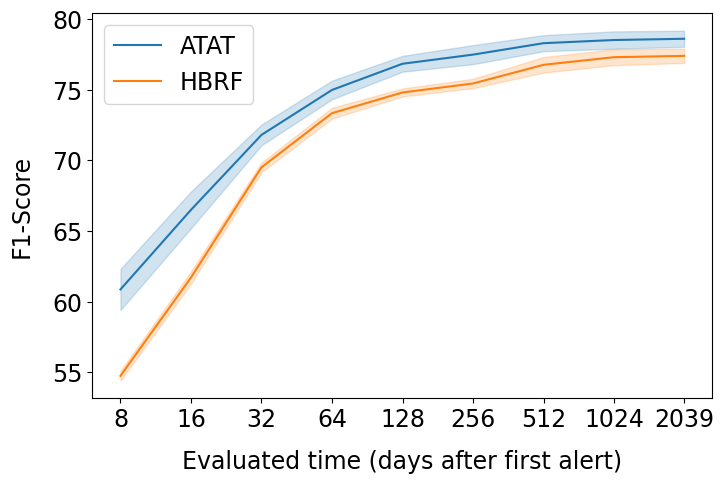

In [11]:
# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 5))

# Graficar los datos con barras de error
#ax.plot(days, combined_f1, linestyle='-', label='ATAT + HBRF', color='tab:green')
ax.plot(days, atat_f1, linestyle='-', label='ATAT', color='tab:blue')
ax.plot(days, hbrf_f1, linestyle='-', label='HBRF', color='tab:orange')

#ax.fill_between(days, np.array(combined_f1) - np.array(combined_f1_err), np.array(combined_f1) + np.array(combined_f1_err), color='tab:green', alpha=0.2)
ax.fill_between(days, np.array(atat_f1) - np.array(atat_f1_err), np.array(atat_f1) + np.array(atat_f1_err), color='tab:blue', alpha=0.2)
ax.fill_between(days, np.array(hbrf_f1) - np.array(hbrf_f1_err), np.array(hbrf_f1) + np.array(hbrf_f1_err), color='tab:orange', alpha=0.2)


# Resaltar el máximo F1-score de todos los modelos
max_f1 = max(max(atat_f1), max(hbrf_f1)) #, max(combined_f1)) 
max_idx = None
max_day = None

# Determinar a qué modelo y día pertenece el máximo F1-score
for idx, (a, h) in enumerate(zip(atat_f1, hbrf_f1)): # combined_f1
    if max_f1 in [a, h]:  # Verificar a qué curva pertenece
        max_idx = idx
        max_day = days[idx]
        break

# Configurar el eje X con escala logarítmica en base 2
list_time_to_eval = sorted(days)  # Asegurar que los valores estén ordenados
ax.set_xscale('log', base=2)
ax.set_xticks(list_time_to_eval)

# Configurar etiquetas, título y límites
fs = 17
#ax.set_title('F1-Score by Evaluation Time', fontsize=fs + 2, fontweight='bold', pad=15)
ax.set_xlabel('Evaluated time (days after first alert)', fontsize=fs, labelpad=13)
ax.set_ylabel('F1-Score', fontsize=fs, labelpad=13)
ax.tick_params(axis='y', labelsize=fs)
ax.set_xticklabels(list_time_to_eval, fontsize=fs)
#ax.set_ylim(51, 79)
ax.legend(fontsize=fs)

# Mostrar la gráfica
plt.savefig(f"{path_save_imgs}/eval_time_bottom_lvl_new_tax.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_confusion_matrix(matrices, order_classes, class_hierarchy=None, path_save=None, figsize=(13, 13), shrink=0.675):
    # Calculando la media y la desviación estándar
    median_matrix = np.median(matrices, axis=0)
    p5_matrix = np.abs(median_matrix - np.percentile(matrices, 5, axis=0))
    p95_matrix = np.abs(median_matrix - np.percentile(matrices, 95, axis=0)) 

    matrices_norm = np.array([m / m.sum(axis=1, keepdims=True) for m in matrices])
    matrices_norm = np.nan_to_num(matrices_norm)
    mean_matrices_norm = np.mean(matrices_norm, axis=0)
        
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    #norm = mcolors.Normalize(vmin=0, vmax=np.max(median_matrix))
    #median_matrix = 
    im = ax.imshow(np.around(mean_matrices_norm, decimals=2), interpolation='nearest', cmap=cmap, aspect=.9, vmax=1)#, #norm=norm)

    #divider = make_axes_locatable(ax)
    #cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, ax=ax, pad=0.02, aspect=40, shrink=shrink)
    cbar.ax.tick_params(labelsize=17)

    # color map
    new_color = cmap(1.0) 

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(median_matrix.shape[0]):
        for j in range(median_matrix.shape[1]):
            mean_val = int(median_matrix[i, j])
            p5_val = int(p5_matrix[i, j])
            p95_val = int(p95_matrix[i, j])

            text = f'{mean_val}'
            text_p95 = f'+{p95_val}' #if p95_val != 0 else ''  # P95 arriba
            text_p5 = f'−{p5_val}' #if p5_val != 0 else ''  # P5 abajo

            color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color

            ax.text(j - 0.13, i, text, ha="center", va="center", color=color, fontsize=18.5)
            ax.text(j + 0.018, i - 0.15, text_p95, ha="left", va="bottom", color=color, fontsize=14)
            ax.text(j + 0.018, i + 0.15, text_p5, ha="left", va="top", color=color, fontsize=14)

            #if mean_matrices_norm[i, j] >= 0.005:
            #    text = f'{mean_val}'
            #    text_p95 = f'+{p95_val}' #if p95_val != 0 else ''  # P95 arriba
            #    text_p5 = f'−{p5_val}' #if p5_val != 0 else ''  # P5 abajo
#
            #    color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color
#
            #    ax.text(j - 0.13, i, text, ha="center", va="center", color=color, fontsize=15.5)
            #    ax.text(j + 0.018, i - 0.15, text_p95, ha="left", va="bottom", color=color, fontsize=11)
            #    ax.text(j + 0.018, i + 0.15, text_p5, ha="left", va="top", color=color, fontsize=11)
            #else:
            #    text = f'{mean_val}'
            #    color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color
            #    ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)

    # Ajustes finales y mostrar la gráfica
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    if class_hierarchy is not None:
        for class_list in class_hierarchy.values():
            indices = [order_classes.index(cls) for cls in class_list if cls in order_classes]
            if indices:
                min_idx, max_idx = min(indices), max(indices)
                rect = patches.Rectangle(
                    (min_idx - 0.5, min_idx - 0.5),  # Esquina superior izquierda
                    max_idx - min_idx + 1,  # Ancho
                    max_idx - min_idx + 1,  # Alto
                    linewidth=2, edgecolor="black", facecolor='none', clip_on=False
                )
                ax.add_patch(rect)

    ax.set_ylabel('True Label', fontsize=17)
    ax.set_xlabel('Predicted Label', fontsize=17)

    plt.setp(ax.get_xticklabels(), rotation=65, ha='center', va='top', rotation_mode="default")
    plt.tight_layout()

    if path_save is not None:
        plt.savefig(f"{path_save}", format="pdf", bbox_inches="tight")

    plt.show()

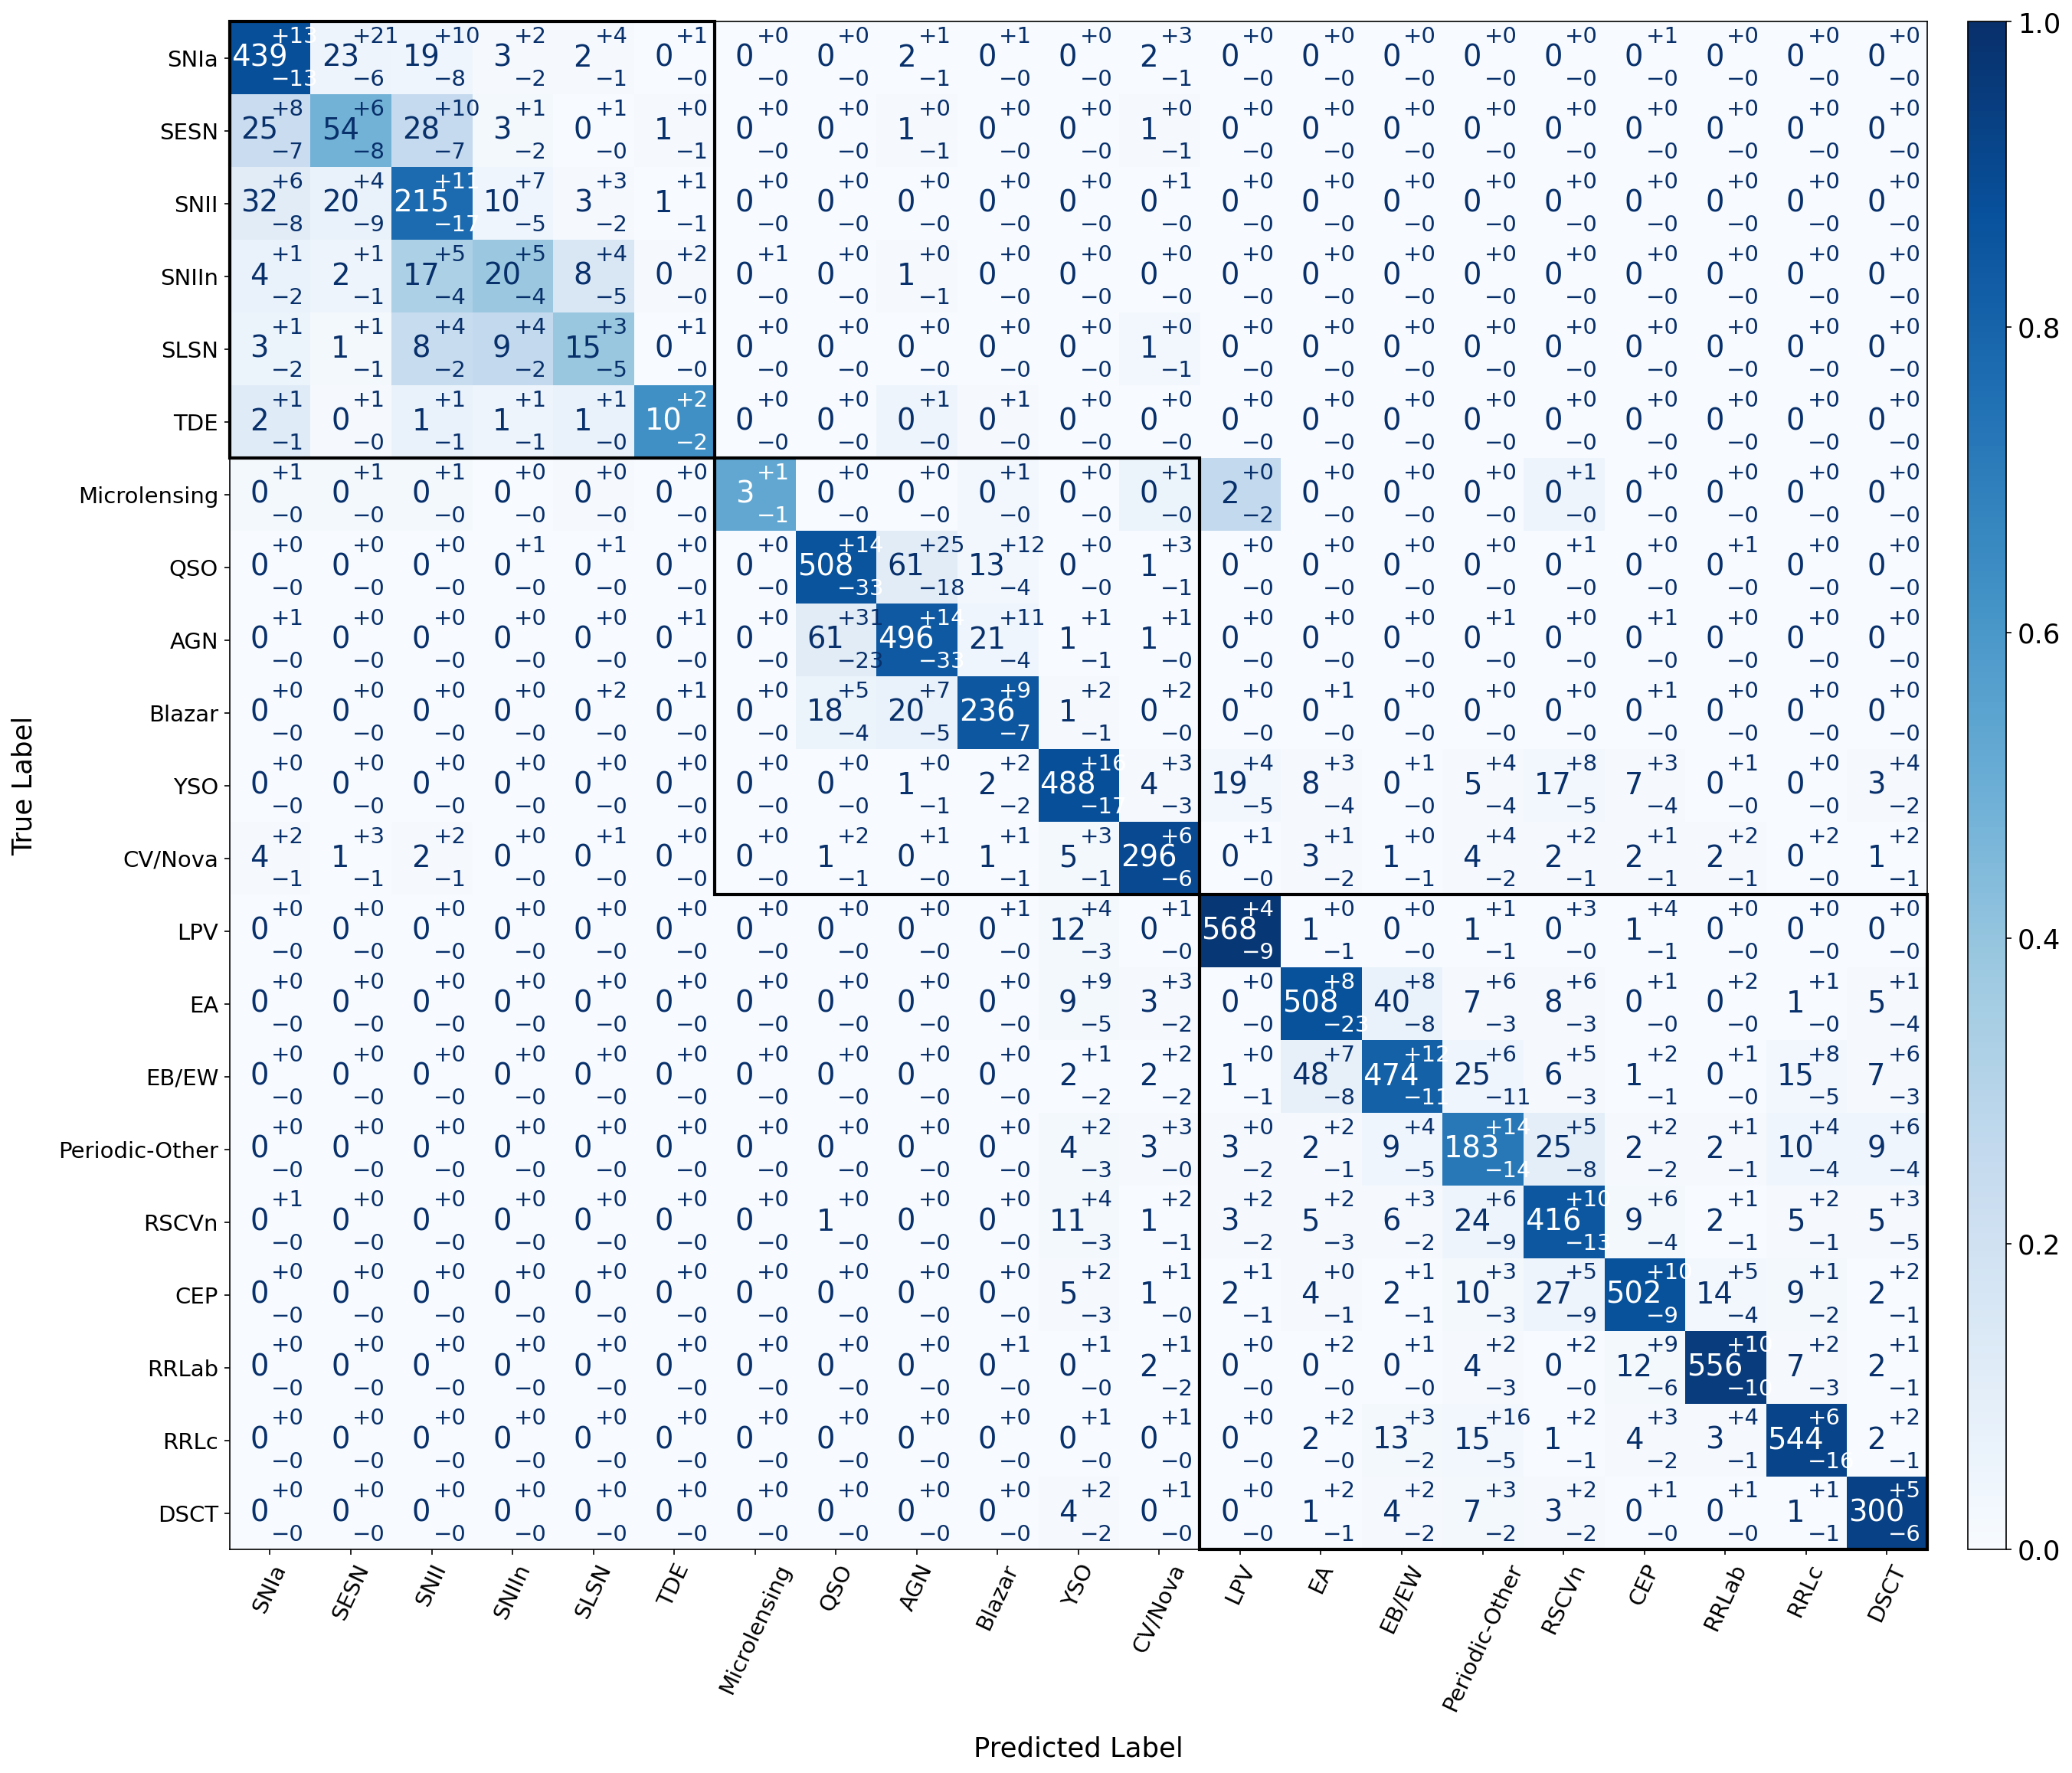

In [13]:
matrices = confusion_matrices['None']['ATAT']
path_save = f'{path_save_imgs}/cm_atat_bottom_lvl_new_tax.pdf'
get_confusion_matrix(matrices, order_classes, class_hierarchy=class_hierarchy, path_save=path_save, figsize=(20,20), shrink=0.675)

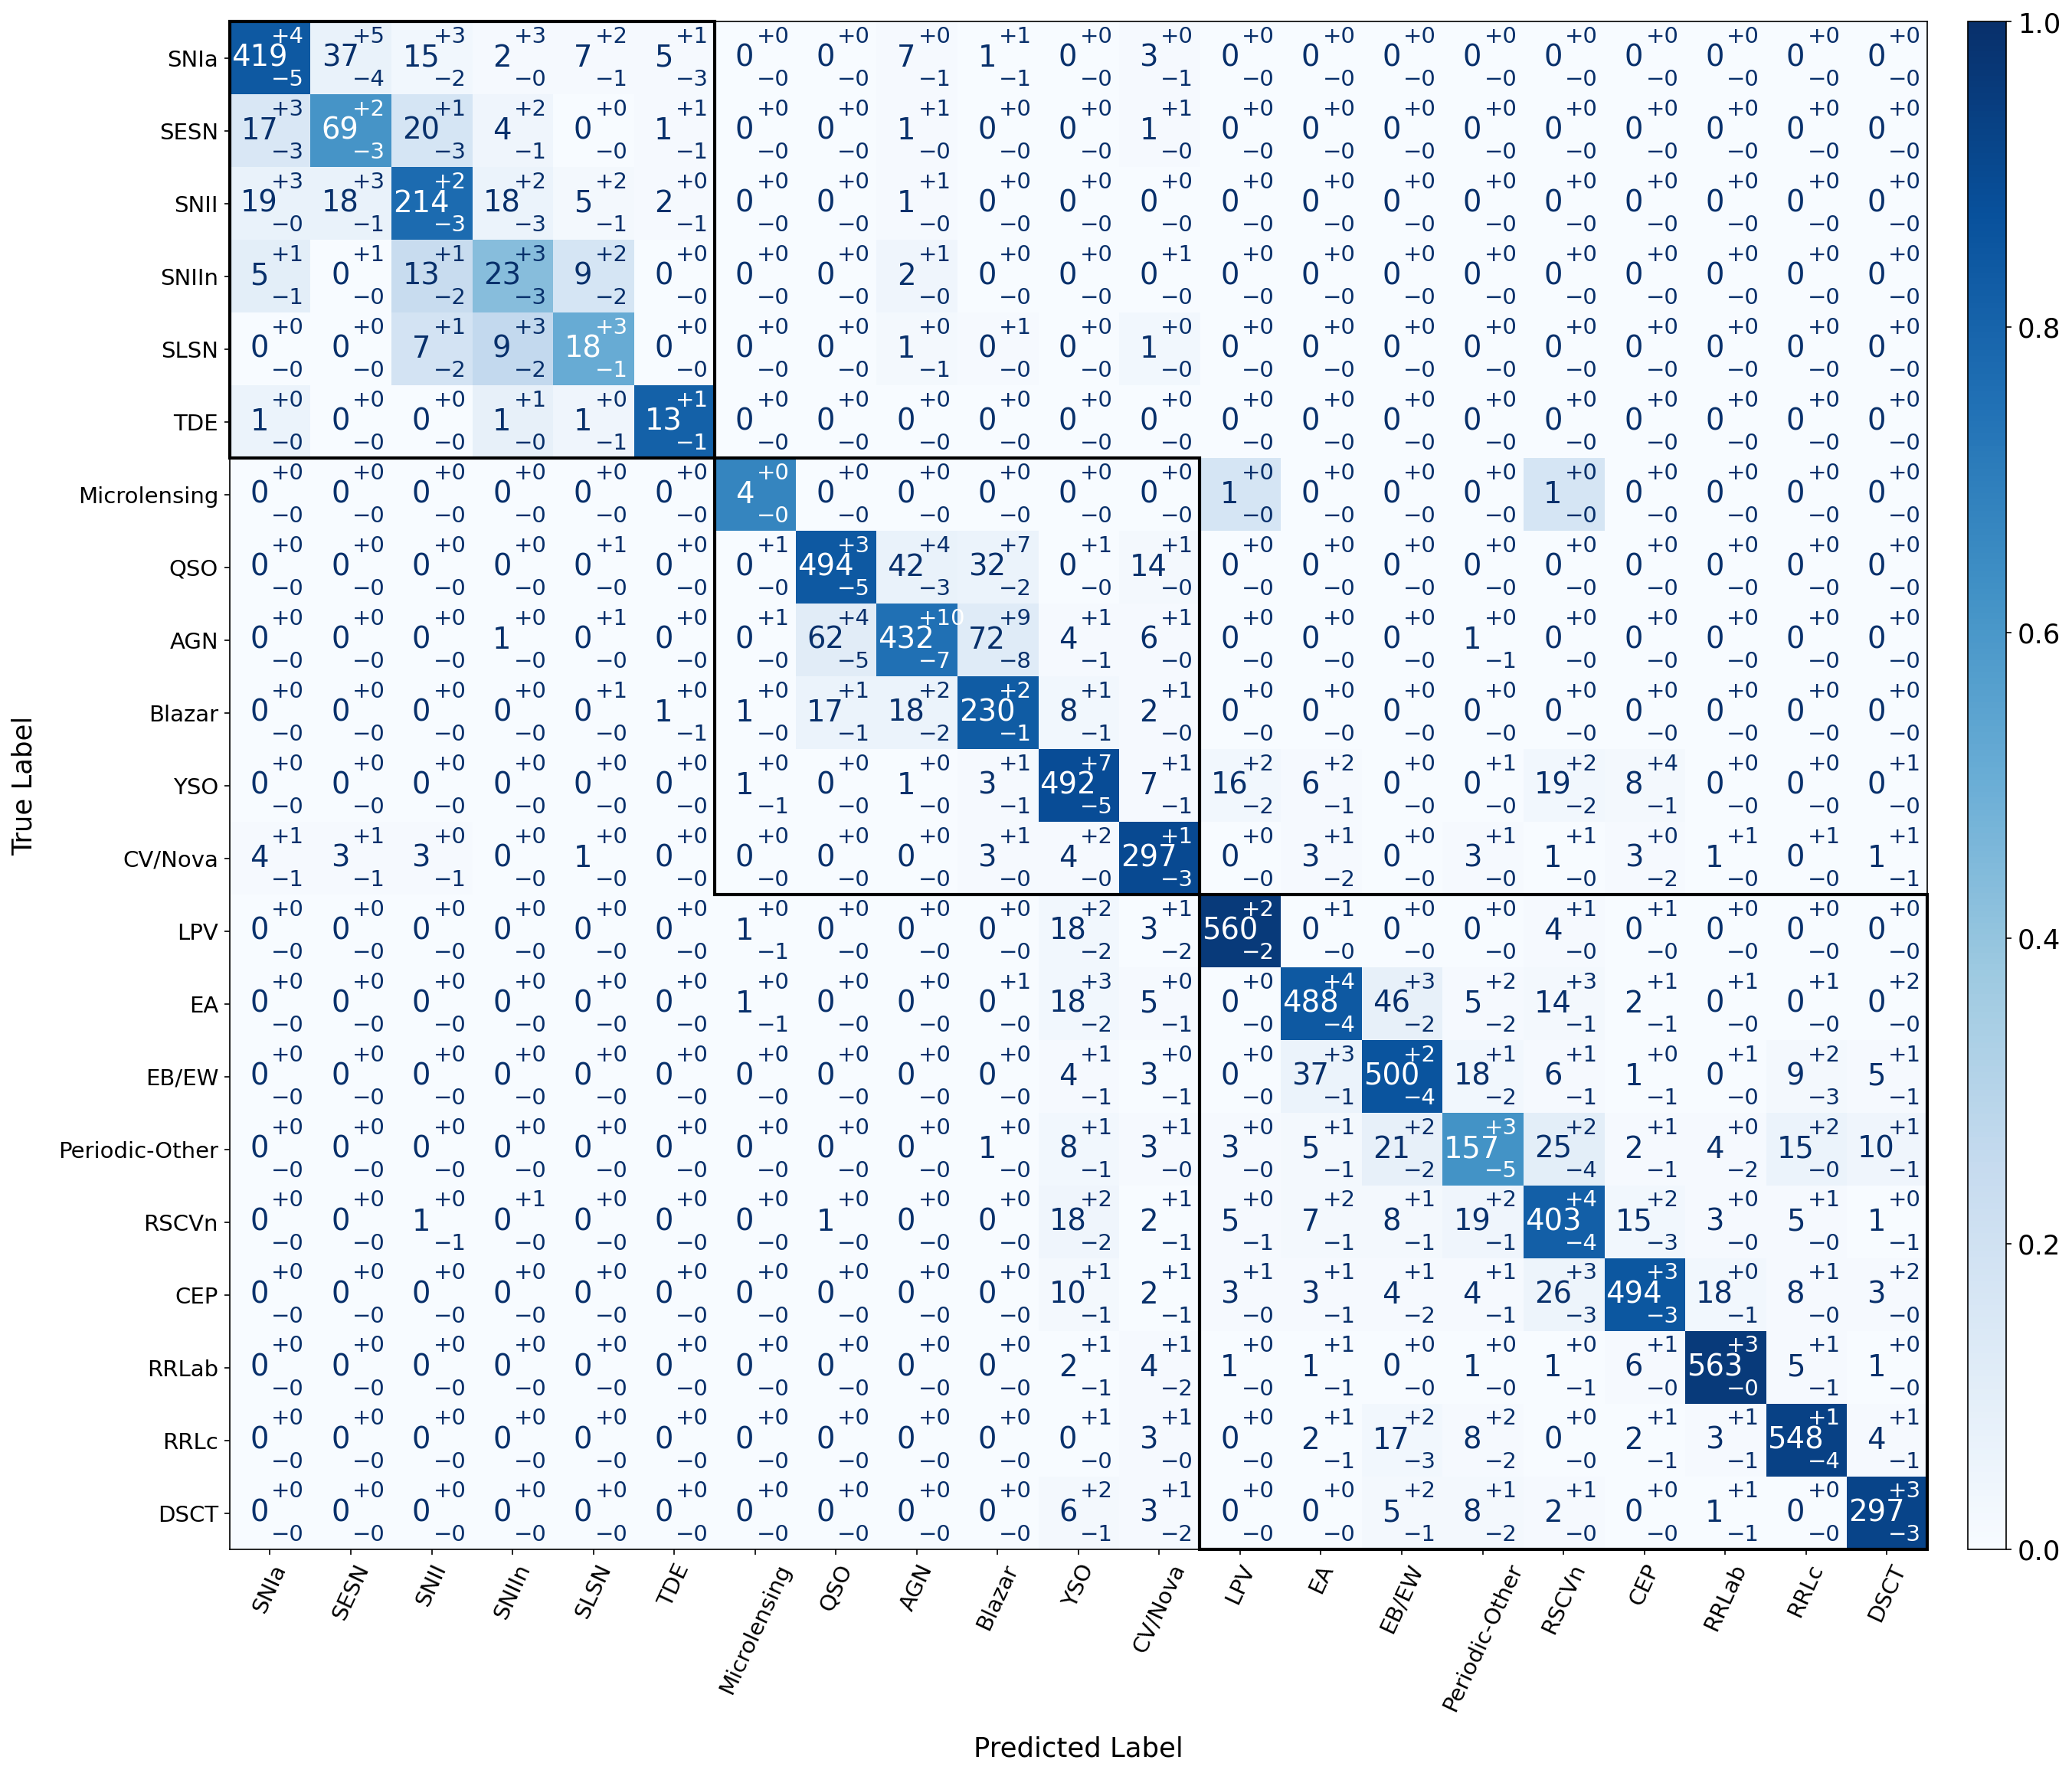

In [14]:
matrices = confusion_matrices['None']['HBRF']
path_save = f'{path_save_imgs}/cm_hbrf_bottom_lvl_new_tax.pdf'
get_confusion_matrix(matrices, order_classes, class_hierarchy=class_hierarchy, path_save=path_save, figsize=(20,20), shrink=0.675)

In [15]:
#matrices = confusion_matrices['None']['Combined']
#path_save = f'{path_save_imgs}/cm_combined_bottom_lvl_new_tax.pdf'
#get_confusion_matrix(matrices, order_classes, class_hierarchy=class_hierarchy, path_save=path_save, figsize=(20,20), shrink=0.675)